# SFT Training — Evidence-First (EF) & Contrastive (CT)

Fine-tunes GPT-4.1-nano on the two new justification-style datasets generated in `DataGeneration_SFT_v2.ipynb`.
Covers: data upload, job submission, monitoring, and label-accuracy evaluation.

- **EF (evidence-first)**: teacher opens with a quote/paraphrase of the passage, then draws the verdict.
- **CT (contrastive)**: teacher explicitly names and dismisses all three labels in one sentence.

In [ ]:
import os
import json
import time
import re
import csv
import io
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential

RESOURCE_GROUP = "cis-5270-team-10"
OPENAI_API_KEY = ""

OPENAI_ENDPOINT = f"https://{RESOURCE_GROUP}.openai.azure.com"
SUBSCRIPTION_ID = ""

os.environ["AZURE_SUBSCRIPTION_ID"] = SUBSCRIPTION_ID
os.environ["AZURE_RESOURCE_GROUP"]  = "CIS-5270"
os.environ["AZURE_AOAI_ACCOUNT"]    = RESOURCE_GROUP
os.environ["AZURE_OPENAI_API_KEY"]  = OPENAI_API_KEY
os.environ["AZURE_OPENAI_ENDPOINT"] = OPENAI_ENDPOINT

CREDENTIAL = DefaultAzureCredential()

openai_client = AzureOpenAI(
    api_key=OPENAI_API_KEY,
    azure_endpoint=OPENAI_ENDPOINT,
    api_version="2025-04-01-preview",
)

BASE_MODEL = "gpt-4.1-nano-2025-04-14"

print("Connected to Azure OpenAI")

Connected to Azure OpenAI


## Step 1: Upload Training and Validation Files

In [2]:
# Evidence-First upload
EF_TRAIN_PATH = "data/generated/sft_data_ef_upload.jsonl"
EF_VAL_PATH   = "data/generated/sft_val_ef_upload.jsonl"

print("Uploading EF training file...")
with open(EF_TRAIN_PATH, "rb") as f:
    ef_train_file = openai_client.files.create(file=f, purpose="fine-tune")
ef_train_file_id = ef_train_file.id
print(f"EF training file id: {ef_train_file_id}")

print("Uploading EF validation file...")
with open(EF_VAL_PATH, "rb") as f:
    ef_val_file = openai_client.files.create(file=f, purpose="fine-tune")
ef_val_file_id = ef_val_file.id
print(f"EF validation file id: {ef_val_file_id}")

print("Waiting for EF file processing...")
openai_client.files.wait_for_processing(ef_train_file_id)
openai_client.files.wait_for_processing(ef_val_file_id)
print("EF files ready!")

Uploading EF training file...
EF training file id: file-56b39f6aa3264a4caf52f56382e99896
Uploading EF validation file...
EF validation file id: file-9c1c998c62e9440c836078495782049c
Waiting for EF file processing...
EF files ready!


In [3]:
# Contrastive upload
CT_TRAIN_PATH = "data/generated/sft_data_ct_upload.jsonl"
CT_VAL_PATH   = "data/generated/sft_val_ct_upload.jsonl"

print("Uploading CT training file...")
with open(CT_TRAIN_PATH, "rb") as f:
    ct_train_file = openai_client.files.create(file=f, purpose="fine-tune")
ct_train_file_id = ct_train_file.id
print(f"CT training file id: {ct_train_file_id}")

print("Uploading CT validation file...")
with open(CT_VAL_PATH, "rb") as f:
    ct_val_file = openai_client.files.create(file=f, purpose="fine-tune")
ct_val_file_id = ct_val_file.id
print(f"CT validation file id: {ct_val_file_id}")

print("Waiting for CT file processing...")
openai_client.files.wait_for_processing(ct_train_file_id)
openai_client.files.wait_for_processing(ct_val_file_id)
print("CT files ready!")

Uploading CT training file...
CT training file id: file-9396a93ee47d43ea8c882e7c55e8892c
Uploading CT validation file...
CT validation file id: file-35911e45c4a64c72a2600f5d7a15b6b7
Waiting for CT file processing...
CT files ready!


## Step 2: Submit Fine-Tuning Jobs

Each style gets one job using the best hyperparameters found in SFT.ipynb (sft_c1: lr=1.0, epochs=1, batch=1).

| Config | Style | LR multiplier | Epochs | Batch size |
|--------|-------|--------------|--------|------------|
| sft_ef | evidence-first | 1.0 | 1 | 1 |
| sft_ct | contrastive    | 1.0 | 1 | 1 |

In [4]:
FT_CONFIGS = [
    {"name": "sft_ef", "train_file": ef_train_file_id, "val_file": ef_val_file_id,
     "learning_rate_multiplier": 1.0, "n_epochs": 1, "batch_size": 1},
    {"name": "sft_ct", "train_file": ct_train_file_id, "val_file": ct_val_file_id,
     "learning_rate_multiplier": 1.0, "n_epochs": 1, "batch_size": 1},
]

jobs = {}
for cfg in FT_CONFIGS:
    job = openai_client.fine_tuning.jobs.create(
        model=BASE_MODEL,
        training_file=cfg["train_file"],
        validation_file=cfg["val_file"],
        method={
            "type": "supervised",
            "supervised": {
                "hyperparameters": {
                    "n_epochs":                 cfg["n_epochs"],
                    "batch_size":               cfg["batch_size"],
                    "learning_rate_multiplier": cfg["learning_rate_multiplier"],
                },
            },
        },
        extra_body={"trainingType": "GlobalStandard"},
        suffix=cfg["name"],
    )
    jobs[cfg["name"]] = job.id
    print(f"{cfg['name']}: job_id={job.id}  status={job.status}")

print("\nfine-tuning jobs submitted")

sft_ef: job_id=ftjob-4de6f7578f6947fea06a9945c7e6dd7f  status=pending
sft_ct: job_id=ftjob-a1a4b0b06a584efcbb83067d11e5608f  status=pending

fine-tuning jobs submitted


## Step 3: Monitor Jobs and Collect Loss Curves

In [6]:
def monitor_jobs(jobs, poll_interval=60):
    """Poll jobs until done, scraping step-level loss from events for a live progress view.
    Returns the scraped curves (noisy) AND a dict of result_file_ids for clean CSV fetching."""
    scraped = {name: [] for name in jobs}
    result_file_ids = {}
    pending = dict(jobs)
    seen_steps = {name: set() for name in jobs}

    while pending:
        for name, job_id in list(pending.items()):
            job = openai_client.fine_tuning.jobs.retrieve(job_id)

            if job.status in ("succeeded", "failed", "cancelled"):
                print(f"{name}: {job.status}  model={job.fine_tuned_model}")
                if job.result_files:
                    result_file_ids[name] = job.result_files[0]
                    print(f"  result file: {result_file_ids[name]}")
                del pending[name]
                continue

            # page through all recent events to catch every step
            events = []
            after = None
            while True:
                page = openai_client.fine_tuning.jobs.list_events(
                    job_id, limit=100, after=after
                )
                batch = list(page)
                if not batch:
                    break
                events.extend(batch)
                after = batch[-1].id
                if len(batch) < 100:
                    break

            for ev in reversed(events):
                m = re.search(r"Step\s+(\d+).*?loss[=:\s]+([0-9.]+)", ev.message, re.IGNORECASE)
                if m:
                    step = int(m.group(1))
                    if step not in seen_steps[name]:
                        seen_steps[name].add(step)
                        scraped[name].append({"step": step, "loss": float(m.group(2))})

            latest = events[0].message if events else "no events"
            n_pts = len(scraped[name])
            print(f"{name}: {job.status} | pts={n_pts} | {latest[:80]}")

        if pending:
            print(f"  waiting {poll_interval}s...\n")
            time.sleep(poll_interval)

    os.makedirs("data/results", exist_ok=True)
    scraped_path = "data/results/sft_ef_ct_loss_curves.json"
    with open(scraped_path, "w") as f:
        json.dump(scraped, f, indent=2)
    print(f"\nscraped loss curves saved to {scraped_path}")
    print(f"result file IDs: {result_file_ids}")
    return scraped, result_file_ids

scraped_curves, result_file_ids = monitor_jobs(jobs)

sft_ef: running | pts=49 | Step 480: training loss=1.3845261335372925
sft_ct: running | pts=148 | Step 1470: training loss=0.3660130202770233
  waiting 60s...

sft_ef: running | pts=49 | Step 480: training loss=1.3845261335372925
sft_ct: running | pts=148 | Step 1470: training loss=0.3660130202770233
  waiting 60s...

sft_ef: running | pts=99 | Step 980: training loss=0.5120221972465515
sft_ct: running | pts=148 | Step 1470: training loss=0.3660130202770233
  waiting 60s...

sft_ef: running | pts=99 | Step 980: training loss=0.5120221972465515
sft_ct: running | pts=148 | Step 1470: training loss=0.3660130202770233
  waiting 60s...

sft_ef: running | pts=99 | Step 980: training loss=0.5120221972465515
sft_ct: running | pts=148 | Step 1470: training loss=0.3660130202770233
  waiting 60s...

sft_ef: running | pts=99 | Step 980: training loss=0.5120221972465515
sft_ct: running | pts=148 | Step 1470: training loss=0.3660130202770233
  waiting 60s...

sft_ef: running | pts=99 | Step 980: tra

model=gpt-4.1-nano-2025-04-14.ft-4de6f7578f6947fea06a9945c7e6dd7f-sft_ef

model=gpt-4.1-nano-2025-04-14.ft-a1a4b0b06a584efcbb83067d11e5608f-sft_ct



### Val Metrics from Result Files

Fetch the Azure result CSV (one row per training step) to get per-checkpoint val loss and token accuracy — same approach as SFT.ipynb.

In [7]:
def safe_float(s):
    try: return float(s)
    except: return None

def fetch_clean_curves(result_file_ids):
    """Download Azure result CSVs and parse into step-aligned train/val loss arrays."""
    curves = {}
    for name, fid in result_file_ids.items():
        content = openai_client.files.content(fid).read().decode("utf-8")
        rows = list(csv.DictReader(io.StringIO(content)))
        steps      = [int(r["step"]) for r in rows]
        train_loss = [safe_float(r.get("train_loss")) for r in rows]
        valid_loss = [safe_float(r.get("valid_loss")) for r in rows]
        full_valid_loss = [safe_float(r.get("full_valid_loss")) for r in rows]
        full_valid_acc  = [safe_float(r.get("full_valid_mean_token_accuracy")) for r in rows]
        curves[name] = {
            "steps": steps,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
            "full_valid_loss": full_valid_loss,
            "full_valid_acc": full_valid_acc,
        }
        print(f"{name}: {len(rows)} rows from result file {fid}")
    return curves

# fetch and save clean curves
clean_curves = fetch_clean_curves(result_file_ids)

CLEAN_PATH = "data/results/sft_ef_ct_loss_curves_clean.json"
with open(CLEAN_PATH, "w") as f:
    json.dump(clean_curves, f, indent=2)
print(f"clean curves saved to {CLEAN_PATH}")

# summary table
print("\nVal Metrics Summary\n")
print(f"{'Config':<10} {'Steps':>6}  {'Final Train':>12}  {'Final Valid':>12}  {'Min Valid':>10}")
print("-" * 60)
for name, data in clean_curves.items():
    tl = [v for v in data["train_loss"] if v is not None]
    vl = [v for v in data["valid_loss"] if v is not None]
    print(f"{name:<10} {len(data['steps']):>6}  "
          f"{tl[-1]:>12.4f}  {vl[-1] if vl else float('nan'):>12.4f}  "
          f"{min(vl) if vl else float('nan'):>10.4f}")

print("\nFull-Val Token Accuracy (epoch checkpoints)\n")
print(f"{'Config':<10} {'Step':>6}  {'Full Val Loss':>14}  {'Token Accuracy':>15}")
print("-" * 55)
for name, data in clean_curves.items():
    for step, loss, acc in zip(data["steps"], data["full_valid_loss"], data["full_valid_acc"]):
        if acc is not None:
            print(f"{name:<10} {step:>6}  {loss:>14.4f}  {acc:>15.4f}")

sft_ct: 3000 rows from result file file-56946f57944f450c921e1ff6c49ca62b
sft_ef: 3000 rows from result file file-13ef736a80df4371a05e3d99bb7ded61
clean curves saved to data/results/sft_ef_ct_loss_curves_clean.json

Val Metrics Summary

Config      Steps   Final Train   Final Valid   Min Valid
------------------------------------------------------------
sft_ct       3000        0.2988        0.2797      0.1716
sft_ef       3000        0.2477        0.5333      0.0887

Full-Val Token Accuracy (epoch checkpoints)

Config       Step   Full Val Loss   Token Accuracy
-------------------------------------------------------
sft_ct       3000          0.3493           0.8873
sft_ef       3000          0.3205           0.9004


using clean loss curves from Azure result files


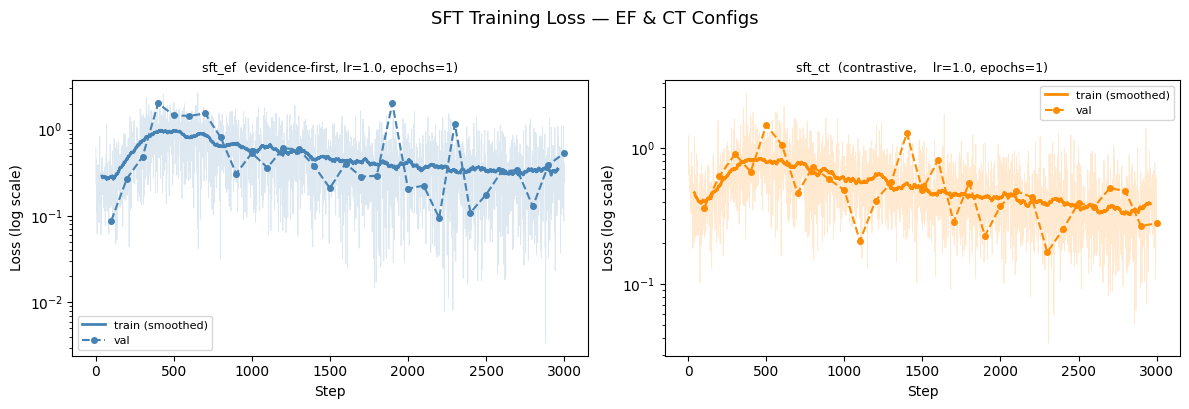

saved to data/results/sft_ef_ct_loss_curves.png


In [8]:
def smooth(values, window=50):
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

# load from disk so this cell is self-contained
CLEAN_PATH = "data/results/sft_ef_ct_loss_curves_clean.json"
SCRAPED_PATH = "data/results/sft_ef_ct_loss_curves.json"

if os.path.exists(CLEAN_PATH):
    with open(CLEAN_PATH) as f:
        plot_curves = json.load(f)
    print("using clean loss curves from Azure result files")
else:
    with open(SCRAPED_PATH) as f:
        scraped = json.load(f)
    plot_curves = {
        name: {"steps": [p["step"] for p in pts],
               "train_loss": [p["loss"] for p in pts],
               "valid_loss": [], "full_valid_loss": [], "full_valid_acc": []}
        for name, pts in scraped.items()
    }
    print("clean curves not yet available, using scraped (noisy)")

configs = ["sft_ef", "sft_ct"]
titles  = {
    "sft_ef": "sft_ef  (evidence-first, lr=1.0, epochs=1)",
    "sft_ct": "sft_ct  (contrastive,    lr=1.0, epochs=1)",
}
colors  = {"sft_ef": "steelblue", "sft_ct": "darkorange"}
WINDOW  = 80

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name in zip(axes, configs):
    if name not in plot_curves:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(titles[name], fontsize=9)
        continue

    data  = plot_curves[name]
    color = colors[name]

    train_pts = [(s, v) for s, v in zip(data["steps"], data["train_loss"]) if v is not None and v > 0]
    valid_pts = [(s, v) for s, v in zip(data["steps"], data["valid_loss"]) if v is not None and v > 0]
    steps_t = np.array([s for s, v in train_pts])
    loss_t  = np.array([v for s, v in train_pts])

    if len(loss_t) > WINDOW:
        smoothed = smooth(loss_t, WINDOW)
        trim = (len(steps_t) - len(smoothed)) // 2
        steps_s = steps_t[trim: trim + len(smoothed)]
        ax.semilogy(steps_t, loss_t, color=color, alpha=0.18, linewidth=0.6)
        ax.semilogy(steps_s, smoothed, color=color, linewidth=2, label="train (smoothed)")
    else:
        ax.plot(steps_t, loss_t, color=color, linewidth=1.2, label="train")

    if valid_pts:
        ax.plot([s for s, v in valid_pts], [v for s, v in valid_pts],
                color=color, linestyle="--", linewidth=1.5, marker="o", markersize=4, label="val")

    ax.set_title(titles[name], fontsize=9)
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss (log scale)" if len(loss_t) > WINDOW else "Loss")
    ax.legend(fontsize=8)

plt.suptitle("SFT Training Loss — EF & CT Configs", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("data/results/sft_ef_ct_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved to data/results/sft_ef_ct_loss_curves.png")

## Fine-Tuned Model IDs

Paste the model IDs reported above after jobs complete:

- sft_ef: `<paste here>`
- sft_ct: `<paste here>`

In [47]:
SFT_DEPLOYMENTS = {
    "sft_ef": "1-nano-2025-04-14-sft_ef",
    "sft_ct": "1-nano-2025-04-14-sft_ct",
}

## Step 4: Evaluate on Dev Set

Each model is evaluated with its own system prompt (the one it was trained on).

In [45]:
EF_SYSTEM = """You are a fact-checking assistant. Given a passage and a claim, write a one-sentence justification using this structure:
1. Quote or closely paraphrase the most relevant part of the passage.
2. State how that evidence supports the verdict.

Format your full response as: LABEL: justification sentence
Label must be one of: SUPPORTED, CONTRADICTED, NOT MENTIONED

The justification must lead with the evidence, not the conclusion."""

CT_SYSTEM = """You are a fact-checking assistant. Given a passage and a claim, write a one-sentence justification that explicitly names all three labels and explains why the correct one applies and the other two do not.

Format: LABEL: justification sentence
Label must be one of: SUPPORTED, CONTRADICTED, NOT MENTIONED
Example structure: \"While the claim is not [wrong_label_1] because [reason] nor [wrong_label_2] because [reason], it is [correct_label] because [evidence].\" """

SYSTEM_PROMPTS = {
    "sft_ef": EF_SYSTEM,
    "sft_ct": CT_SYSTEM,
}

In [6]:
VALID_LABELS = {"SUPPORTED", "CONTRADICTED", "NOT MENTIONED"}

def extract_label(text):
    for lbl in VALID_LABELS:
        if text.upper().startswith(lbl + ":"):
            return lbl
    if text.strip() in VALID_LABELS:
        return text.strip()
    for lbl in sorted(VALID_LABELS, key=len, reverse=True):
        if re.search(rf'\b{lbl}\b', text.upper()):
            return lbl
    return None

def predict_sft(passage, claim, deployment, system_prompt, temperature=0.0):
    user_msg = f"Passage: {passage}\n\nClaim: {claim}"
    for attempt in range(3):
        try:
            resp = openai_client.chat.completions.create(
                model=deployment,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user",   "content": user_msg},
                ],
                temperature=temperature,
                max_tokens=150,
            )
            text = resp.choices[0].message.content.strip()
            label = extract_label(text)
            if label:
                return label, text
        except Exception as e:
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                print(f"  failed after 3 attempts: {e}")
    return None, None

def run_eval(cfg_name, deployment, system_prompt, examples, out_path):
    done_ids = set()
    results = []
    if os.path.exists(out_path):
        with open(out_path) as f:
            for line in f:
                r = json.loads(line)
                done_ids.add(r["id"])
                results.append(r)
        print(f"resuming, {len(done_ids)} already done")

    skipped = 0
    with open(out_path, "a") as out_f:
        for i, ex in enumerate(examples):
            if ex["id"] in done_ids:
                continue
            pred_label, raw = predict_sft(ex["passage"], ex["claim"], deployment, system_prompt)
            if pred_label is None:
                skipped += 1
                continue
            record = {"id": ex["id"], "label": ex["label"], "pred_label": pred_label, "raw": raw}
            out_f.write(json.dumps(record) + "\n")
            out_f.flush()
            results.append(record)
            if (i + 1) % 100 == 0:
                print(f"  [{i+1}/{len(examples)}] skipped={skipped}")

    print(f"done. total={len(results)} skipped={skipped}")
    return results

In [39]:
random.seed(42)

dev_data = []
with open("data/joined/fever_dev_joined.jsonl") as f:
    for line in f:
        dev_data.append(json.loads(line))

buckets = defaultdict(list)
for ex in dev_data:
    buckets[ex["label"]].append(ex)

eval_sample = []
for lbl, items in buckets.items():
    random.shuffle(items)
    eval_sample.extend(items[:334])
random.shuffle(eval_sample)

print(f"dev sample: {len(eval_sample)} examples")
print(Counter(ex["label"] for ex in eval_sample))

dev sample: 1002 examples
Counter({'NOT MENTIONED': 334, 'CONTRADICTED': 334, 'SUPPORTED': 334})


In [41]:
all_results = {}
for cfg_name, deployment in SFT_DEPLOYMENTS.items():
    print(f"Config: {cfg_name}  deployment: {deployment}")
    out_path = f"data/results/{cfg_name}_dev.jsonl"
    results = run_eval(cfg_name, deployment, SYSTEM_PROMPTS[cfg_name], eval_sample, out_path)
    all_results[cfg_name] = results
    print()

Config: sft_ct  deployment: 1-nano-2025-04-14-sft_ct
resuming, 436 already done
  failed after 3 attempts: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: https://go.microsoft.com/fwlink/?linkid=2198766", 'type': None, 'param': 'prompt', 'code': 'content_filter', 'status': 400, 'innererror': {'code': 'ResponsibleAIPolicyViolation', 'content_filter_result': {'hate': {'filtered': True, 'severity': 'medium'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}}}
  failed after 3 attempts: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Pl

## Results: Label Accuracy on Dev Set

In [48]:
def compute_metrics(results):
    labels = ["SUPPORTED", "CONTRADICTED", "NOT MENTIONED"]
    per_class = {lbl: {"correct": 0, "total": 0} for lbl in labels}
    confusion = {true: {pred: 0 for pred in labels} for true in labels}
    total_correct = 0

    for r in results:
        gt, pred = r["label"], r["pred_label"]
        per_class[gt]["total"] += 1
        confusion[gt][pred] += 1
        if pred == gt:
            per_class[gt]["correct"] += 1
            total_correct += 1

    macro_acc = sum(
        per_class[lbl]["correct"] / per_class[lbl]["total"]
        for lbl in labels if per_class[lbl]["total"] > 0
    ) / len(labels)
    overall_acc = total_correct / len(results)

    print(f"  overall accuracy: {overall_acc:.3f}  ({total_correct}/{len(results)})")
    print(f"  macro accuracy:   {macro_acc:.3f}")
    print()
    print("  Per-class accuracy:")
    for lbl in labels:
        c = per_class[lbl]
        acc = c["correct"] / c["total"] if c["total"] else 0
        print(f"    {lbl:20s}: {acc:.3f}  ({c['correct']}/{c['total']})")
    print()
    print("  Confusion matrix (rows=true, cols=pred):")
    col_w = 14
    print(" " * 22 + "".join(f"{lbl[:col_w]:>{col_w}}" for lbl in labels))
    for true_lbl in labels:
        row = f"  {true_lbl:20s}" + "".join(
            f"{confusion[true_lbl][pred_lbl]:>{col_w}}" for pred_lbl in labels
        )
        print(row)

    return macro_acc

# reload from disk so cell is self-contained
all_results = {}
for cfg_name in SFT_DEPLOYMENTS:
    path = f"data/results/{cfg_name}_dev.jsonl"
    if os.path.exists(path):
        records = []
        with open(path) as f:
            for line in f:
                if not line.strip(): continue
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
        all_results[cfg_name] = records
        print(f"loaded {cfg_name}: {len(records)} records")
    else:
        print(f"missing: {path}")

print("\nSFT Dev Results\n")
best_cfg, best_acc = None, 0
for cfg_name, results in all_results.items():
    print(f"Config: {cfg_name}")
    acc = compute_metrics(results)
    if acc > best_acc:
        best_acc, best_cfg = acc, cfg_name
    print()

print(f"Best config: {best_cfg}  (macro accuracy={best_acc:.3f})")

loaded sft_ef: 999 records
loaded sft_ct: 999 records

SFT Dev Results

Config: sft_ef
  overall accuracy: 0.929  (928/999)
  macro accuracy:   0.929

  Per-class accuracy:
    SUPPORTED           : 0.913  (305/334)
    CONTRADICTED        : 0.901  (300/333)
    NOT MENTIONED       : 0.973  (323/332)

  Confusion matrix (rows=true, cols=pred):
                           SUPPORTED  CONTRADICTED NOT MENTIONED
  SUPPORTED                      305            21             8
  CONTRADICTED                    22           300            11
  NOT MENTIONED                    1             8           323

Config: sft_ct
  overall accuracy: 0.906  (905/999)
  macro accuracy:   0.906

  Per-class accuracy:
    SUPPORTED           : 0.796  (266/334)
    CONTRADICTED        : 0.967  (322/333)
    NOT MENTIONED       : 0.955  (317/332)

  Confusion matrix (rows=true, cols=pred):
                           SUPPORTED  CONTRADICTED NOT MENTIONED
  SUPPORTED                      266            65    

## Qualitative Examples: sft_ef

Two correct and two incorrect predictions per class, drawn from the dev results, to illustrate the evidence-first justification style in practice.

In [52]:
import json, os

# load dev results and join with original examples for passage/claim
ef_records = {}
with open("data/results/sft_ef_dev.jsonl") as f:
    for line in f:
        if not line.strip(): continue
        r = json.loads(line)
        ef_records[r["id"]] = r

dev_by_id = {}
with open("data/joined/fever_dev_joined.jsonl") as f:
    for line in f:
        ex = json.loads(line)
        dev_by_id[ex["id"]] = ex

LABELS = ["SUPPORTED", "CONTRADICTED", "NOT MENTIONED"]

for true_label in LABELS:
    correct   = [r for r in ef_records.values() if r["label"] == true_label and r["pred_label"] == true_label][:2]
    incorrect = [r for r in ef_records.values() if r["label"] == true_label and r["pred_label"] != true_label][:2]

    print(f"{'='*70}")
    print(f"TRUE LABEL: {true_label}")
    print(f"{'='*70}")

    print("\n--- Correct predictions ---")
    for r in correct:
        ex = dev_by_id.get(r["id"], {})
        print(f"  Passage : {ex.get('passage','')[:120]}...")
        print(f"  Claim   : {ex.get('claim','')}")
        print(f"  Output  : {r['raw']}")
        print()

    print("--- Incorrect predictions ---")
    for r in incorrect:
        ex = dev_by_id.get(r["id"], {})
        print(f"  Passage : {ex.get('passage','')[:120]}...")
        print(f"  Claim   : {ex.get('claim','')}")
        print(f"  Predicted: {r['pred_label']}  (true: {r['label']})")
        print(f"  Output  : {r['raw']}")
        print()
    print()

TRUE LABEL: SUPPORTED

--- Correct predictions ---
  Passage : Avul Pakir Jainulabdeen Abdul Kalam better known as A.P.J. Abdul Kalam -LSB- ˈæbdʊl_kəˈlɑːm -RSB- -LRB- 15 October 1931 ...
  Claim   : A. P. J. Abdul Kalam was elected as President of India.
  Output  : SUPPORTED: The passage states that Avul Pakir Jainulabdeen Abdul Kalam, also known as A.P.J. Abdul Kalam, was the 11th President of India from 2002 to 2007, which supports the claim that he was elected as President of India.

  Passage : The Invisible Man is an American 1933 Pre-Code science fiction horror film based on H. G. Wells ' science fiction novel ...
  Claim   : The Invisible Man was based on a H. G. Wells novel.
  Output  : SUPPORTED: The passage states that The Invisible Man is based on H. G. Wells' science fiction novel The Invisible Man, which supports the claim that the film was based on a H. G. Wells novel.

--- Incorrect predictions ---
  Passage : No Strings Attached is a 2011 American romantic comedy film 

## Step 5: Final Test Evaluation (Best Config Only)

Run once on the held-out test set using the best config selected from dev.
Do not re-run after inspecting results.

In [51]:
BEST_CONFIG = best_cfg
BEST_DEPLOYMENT = SFT_DEPLOYMENTS[BEST_CONFIG]

random.seed(42)
test_data = []
with open("data/joined/fever_test_joined.jsonl") as f:
    for line in f:
        test_data.append(json.loads(line))

test_buckets = defaultdict(list)
for ex in test_data:
    test_buckets[ex["label"]].append(ex)

test_sample = []
for lbl, items in sorted(test_buckets.items()):
    random.shuffle(items)
    test_sample.extend(items[:334])  # ~1000 total, stratified
random.shuffle(test_sample)

print(f"test sample: {len(test_sample)} examples")
print(Counter(ex["label"] for ex in test_sample))

print(f"\nRunning final test eval: {BEST_CONFIG} ({BEST_DEPLOYMENT})")
test_results = run_eval(
    BEST_CONFIG, BEST_DEPLOYMENT, SYSTEM_PROMPTS[BEST_CONFIG],
    test_sample, f"data/results/sft_{BEST_CONFIG}_test.jsonl"
)

print(f"\nFinal Test Result: {BEST_CONFIG}")
compute_metrics(test_results)

test sample: 1002 examples
Counter({'CONTRADICTED': 334, 'SUPPORTED': 334, 'NOT MENTIONED': 334})

Running final test eval: sft_ef (1-nano-2025-04-14-sft_ef)
resuming, 633 already done
  failed after 3 attempts: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: https://go.microsoft.com/fwlink/?linkid=2198766", 'type': None, 'param': 'prompt', 'code': 'content_filter', 'status': 400, 'innererror': {'code': 'ResponsibleAIPolicyViolation', 'content_filter_result': {'hate': {'filtered': True, 'severity': 'medium'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}}}
  failed after 3 attempts: Error code: 400 - {'error': {'messa

0.9079311257004065